# 8. Stress Testing

This notebook evaluates portfolio risk under adverse market scenarios.

The analysis covers:

1. Historical Scenario Stress Testing
2. Hypothetical Scenario Stress Testing
3. Single-Factor Sensitivity Analysis
4. Multi-Factor Stress Scenarios
5. Stress Test Results

The portfolio consists of SPY, QQQ, IWM, TLT, and GLD with fixed portfolio weights.

The objective is to assess how the portfolio responds to severe market conditions and identify the scenarios and risk factors that generate the largest portfolio losses.

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parents[1]
sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from project_01_market_risk_engine.src.data import download_prices

In [3]:
TICKERS = ["SPY", "QQQ", "IWM", "TLT", "GLD"]

START_DATE = "2015-01-01"
END_DATE = "2026-01-01"

weights = pd.Series({
    "SPY":0.30, 
    "QQQ":0.20, 
    "IWM":0.15, 
    "TLT":0.20, 
    "GLD":0.15
    
})


In [4]:
prices = download_prices(
    tickers=TICKERS,
    start=START_DATE,
    end=END_DATE
)

returns = prices.pct_change().dropna()

[*********************100%***********************]  5 of 5 completed


## 1. Historical Scenario Stress Testing

Historical scenario stress testing evaluates the portfolio under severe market conditions that actually occurred in the historical sample.

Rather than estimating a loss from a probability distribution, the portfolio is revalued using the asset returns observed during a specific historical stress period.

This provides a direct view of how the current portfolio would have behaved under a past market crisis.

In [ ]:
portfolio_returns = returns @ weights

historical_stress = portfolio_returns.sort_values().head(10).to_frame(name="Portfolio Return")
historical_stress["Portfolio Loss"] = -historical_stress["Portfolio Return"]
historical_stress

,Portfolio Returns,Portfolio Loss
Date,,
2020-03-12,-0.068361,0.068361
2020-03-16,-0.065449,0.065449
2020-03-18,-0.047170,0.047170
2020-03-09,-0.046237,0.046237
2020-03-11,-0.040769,0.040769
2025-04-04,-0.038007,0.038007
2022-06-13,-0.037974,0.037974
2020-06-11,-0.035948,0.035948
2025-04-03,-0.035107,0.035107


The table shows the ten largest historical daily portfolio losses in the sample.

These observations represent realized adverse scenarios rather than probability-based estimates. They provide a direct view of the portfolio's behavior during the most severe market moves contained in the historical data.

### Asset-Level Stress Contributions

The portfolio-level stress return is driven by the individual asset returns observed during each adverse market day.

Examining asset-level returns helps identify which positions were responsible for the portfolio's losses under historical stress conditions.

In [7]:
stress_dates = historical_stress.head().index
historical_asset_returns = returns.loc[stress_dates].copy()
historical_asset_returns


Ticker,GLD,IWM,QQQ,SPY,TLT
Date,,,,,
2020-03-12,-0.039888,-0.110502,-0.091692,-0.095677,0.006197
2020-03-16,-0.011446,-0.132669,-0.119788,-0.109424,0.064766
2020-03-18,-0.019922,-0.077512,-0.030416,-0.050633,-0.056412
2020-03-09,0.001650,-0.097230,-0.069464,-0.078094,0.027103
2020-03-11,-0.003560,-0.063602,-0.043555,-0.048748,-0.036798


In [10]:
historical_contributions = historical_asset_returns * weights
historical_contributions

Ticker,GLD,IWM,QQQ,SPY,TLT
Date,,,,,
2020-03-12,-0.005983,-0.016575,-0.018338,-0.028703,0.001239
2020-03-16,-0.001717,-0.019900,-0.023958,-0.032827,0.012953
2020-03-18,-0.002988,-0.011627,-0.006083,-0.015190,-0.011282
2020-03-09,0.000248,-0.014584,-0.013893,-0.023428,0.005421
2020-03-11,-0.000534,-0.009540,-0.008711,-0.014624,-0.007360


## 2. Hypothetical Scenario Stress Testing

Hypothetical stress testing evaluates the portfolio under predefined adverse asset-price shocks.

Unlike historical stress testing, the scenarios do not need to correspond to an event that actually occurred. Instead, shocks are specified to represent severe but plausible market conditions.

The portfolio impact is calculated as the weighted sum of the individual asset shocks:

$$
R_p = \sum_{i=1}^{n} w_i R_i
$$

where $w_i$ represents the portfolio weight and $R_i$ represents the scenario return for asset $i$.

In [11]:
hypothetical_scenario = pd.Series({
    
        "SPY": -0.20,
        "QQQ": -0.25,
        "IWM": -0.30,
        "TLT": -0.10,
        "GLD": 0.05,
    
    
})

In [12]:
hypothetical_portfolio_return = hypothetical_scenario @ weights
hypothetical_portfolio_loss = -hypothetical_portfolio_return

print(f"Portfolio Return: {hypothetical_portfolio_return:.2%}")
print(f"Portfolio Loss:   {hypothetical_portfolio_loss:.2%}")

Portfolio Return: -16.75%
Portfolio Loss:   16.75%


In [13]:
hypothetical_contributions = (
    hypothetical_scenario * weights
)

hypothetical_contributions

SPY   -0.0600
QQQ   -0.0500
IWM   -0.0450
TLT   -0.0200
GLD    0.0075
dtype: float64

### Scenario Severity Analysis

To evaluate how portfolio losses change with scenario severity, three hypothetical market environments are considered:

- **Moderate:** broad market decline with limited diversification stress
- **Severe:** larger equity losses combined with declines in defensive assets
- **Extreme:** substantial equity losses and simultaneous stress across multiple asset classes

In [14]:
scenarios = pd.DataFrame(
    {
        "SPY": [-0.10, -0.20, -0.30],
        "QQQ": [-0.12, -0.25, -0.35],
        "IWM": [-0.15, -0.30, -0.40],
        "TLT": [-0.05, -0.10, -0.15],
        "GLD": [0.02, 0.05, -0.05],
    },
    index=["Moderate", "Severe", "Extreme"],
)

scenarios

,SPY,QQQ,IWM,TLT,GLD
Moderate,-0.1,-0.12,-0.15,-0.05,0.02
Severe,-0.2,-0.25,-0.30,-0.10,0.05
Extreme,-0.3,-0.35,-0.40,-0.15,-0.05


In [16]:
scenario_results = scenarios @ weights
scenario_results = pd.DataFrame({
    "Portfolio Return": scenario_results,
    "Portfolio Loss": -scenario_results,
})

scenario_results

,Portfolio Return,Portfolio Loss
Moderate,-0.0835,0.0835
Severe,-0.1675,0.1675
Extreme,-0.2575,0.2575


In [17]:
scenario_contributions = scenarios * weights

scenario_contributions

,SPY,QQQ,IWM,TLT,GLD
Moderate,-0.03,-0.024,-0.0225,-0.01,0.0030
Severe,-0.06,-0.050,-0.0450,-0.02,0.0075
Extreme,-0.09,-0.070,-0.0600,-0.03,-0.0075


## 3. Single-Factor Sensitivity Analysis

Single-factor sensitivity analysis isolates the impact of an adverse shock to one asset while holding the returns of all other assets constant.

This helps identify which portfolio positions have the greatest potential impact on portfolio losses when subjected to increasingly severe individual shocks.

In [21]:
shock_levels = np.linspace(-0.05, -0.30, 6)
single_factor_results = {}

for ticker in TICKERS:
    portfolio_losses = []
    
    for shock in shock_levels:
        scenario = pd.Series(0.0, index = TICKERS)
        scenario[ticker] = shock
        
        portfolio_return = scenario @ weights
        portfolio_losses.append(-portfolio_return)
    
    single_factor_results[ticker] = portfolio_losses
 
 
 
single_factor_sensitivity = pd.DataFrame(
    single_factor_results,
    index=[f"{abs(shock):.0%}" for shock in shock_levels]
)

single_factor_sensitivity.index.name = "Asset Shock"

single_factor_sensitivity   
    

,SPY,QQQ,IWM,TLT,GLD
Asset Shock,,,,,
5%,0.015,0.01,0.0075,0.01,0.0075
10%,0.030,0.02,0.0150,0.02,0.0150
15%,0.045,0.03,0.0225,0.03,0.0225
20%,0.060,0.04,0.0300,0.04,0.0300
25%,0.075,0.05,0.0375,0.05,0.0375
30%,0.090,0.06,0.0450,0.06,0.0450


The resulting table shows the portfolio loss associated with increasingly severe shocks to each individual asset.

Because the analysis holds all other assets at zero return, the results isolate the direct effect of each position's portfolio weight and shock magnitude.

## 4. Multi-Factor Stress Scenarios

Multi-factor stress testing applies simultaneous shocks to multiple assets to represent a coordinated adverse market environment.

Unlike single-factor sensitivity analysis, the shocks can affect several portfolio positions at the same time, allowing the analysis to capture the combined impact of a broad market stress event.

The portfolio return under each scenario is calculated as:

$$
R_p = \sum_{i=1}^{n} w_i R_i
$$

where each $R_i$ represents the scenario shock applied to asset $i$.

In [22]:
multi_factor_scenarios = pd.DataFrame(
    {
        "SPY": [-0.15, -0.20, -0.30],
        "QQQ": [-0.20, -0.25, -0.35],
        "IWM": [-0.20, -0.30, -0.40],
        "TLT": [0.05, -0.10, -0.15],
        "GLD": [0.05, 0.05, -0.05],
    },
    index=[
        "Equity Selloff",
        "Severe Risk-Off",
        "Extreme Market Stress",
    ],
)

multi_factor_scenarios

,SPY,QQQ,IWM,TLT,GLD
Equity Selloff,-0.15,-0.20,-0.2,0.05,0.05
Severe Risk-Off,-0.20,-0.25,-0.3,-0.10,0.05
Extreme Market Stress,-0.30,-0.35,-0.4,-0.15,-0.05


In [23]:
multi_factor_returns = multi_factor_scenarios @ weights

multi_factor_results = pd.DataFrame({
    "Portfolio Return": multi_factor_returns,
    "Portfolio Loss": -multi_factor_returns,
})

multi_factor_results

,Portfolio Return,Portfolio Loss
Equity Selloff,-0.0975,0.0975
Severe Risk-Off,-0.1675,0.1675
Extreme Market Stress,-0.2575,0.2575


In [25]:
multi_factor_contributions = (
    multi_factor_scenarios* weights
)

multi_factor_contributions

,SPY,QQQ,IWM,TLT,GLD
Equity Selloff,-0.045,-0.04,-0.030,0.01,0.0075
Severe Risk-Off,-0.060,-0.05,-0.045,-0.02,0.0075
Extreme Market Stress,-0.090,-0.07,-0.060,-0.03,-0.0075


The multi-factor scenarios illustrate how simultaneous shocks across asset classes can produce substantially larger portfolio losses than isolated single-factor shocks.

The asset-level contributions identify which positions are the primary drivers of portfolio losses under each stress environment.

## 5. Stress Test Results

The stress-testing results are consolidated below to compare portfolio losses across historical and hypothetical scenarios.

This provides a common view of the portfolio's vulnerability under both observed and assumed adverse market conditions.

In [30]:
stress_test_results = pd.DataFrame({
    "Portfolio Loss": [
        historical_stress["Portfolio Loss"].iloc[0],
        scenario_results.loc["Moderate", "Portfolio Loss"],
        scenario_results.loc["Severe", "Portfolio Loss"],
        scenario_results.loc["Extreme", "Portfolio Loss"],
        multi_factor_results.loc["Equity Selloff", "Portfolio Loss"],
        multi_factor_results.loc["Severe Risk-Off", "Portfolio Loss"],
        multi_factor_results.loc["Extreme Market Stress", "Portfolio Loss"],
    ]
}, index=[
    "Worst Historical Day",
    "Hypothetical - Moderate",
    "Hypothetical - Severe",
    "Hypothetical - Extreme",
    "Multi-Factor - Equity Selloff",
    "Multi-Factor - Severe Risk-Off",
    "Multi-Factor - Extreme Stress",
])

stress_test_results


,Portfolio Loss
Worst Historical Day,0.068361
Hypothetical - Moderate,0.083500
Hypothetical - Severe,0.167500
Hypothetical - Extreme,0.257500
Multi-Factor - Equity Selloff,0.097500
Multi-Factor - Severe Risk-Off,0.167500
Multi-Factor - Extreme Stress,0.257500


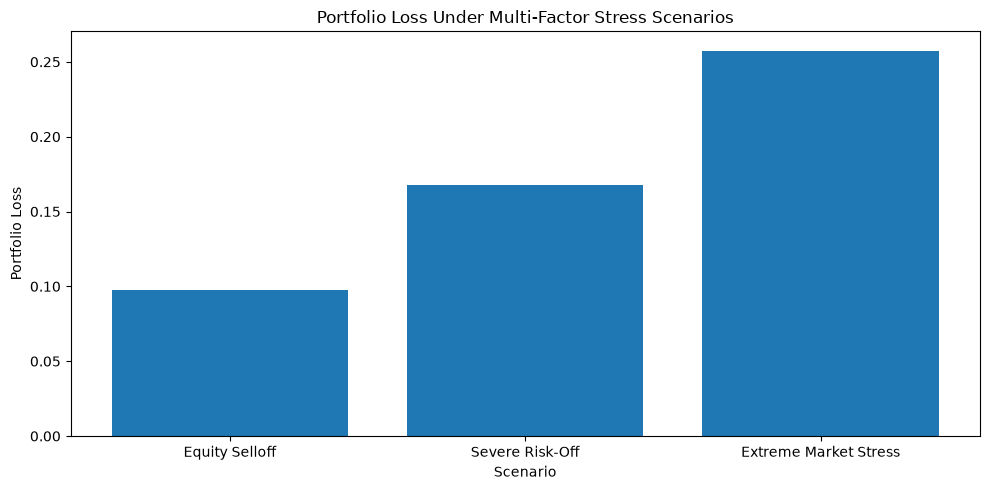

In [28]:
plt.figure(figsize=(10, 5))

plt.bar(
    stress_test_results.index,
    stress_test_results["Portfolio Loss"]
)

plt.ylabel("Portfolio Loss")
plt.xlabel("Scenario")
plt.title("Portfolio Loss Under Multi-Factor Stress Scenarios")

plt.tight_layout()
plt.show()

### Asset Contributions Under Stress

The contribution of each asset to portfolio losses varies across stress scenarios depending on both the magnitude of the shock and the portfolio weight.

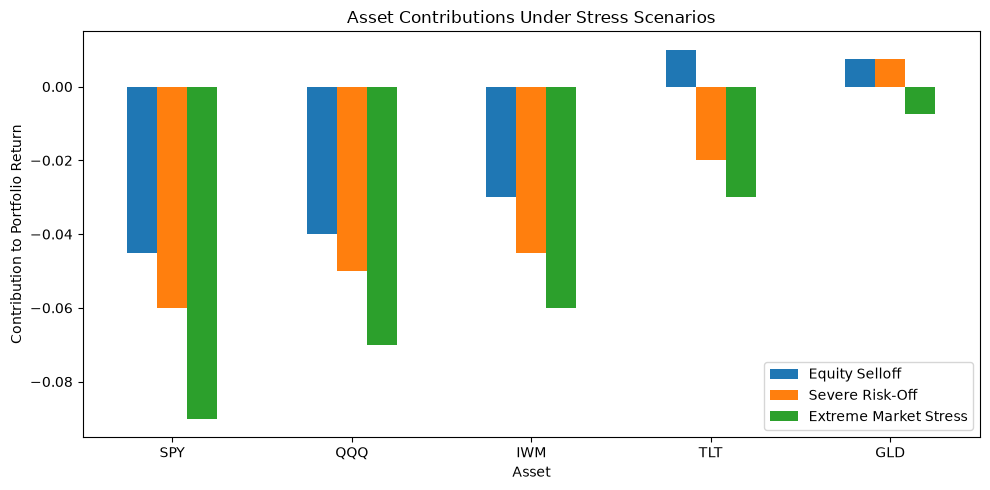

In [29]:
multi_factor_contributions.T.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.ylabel("Contribution to Portfolio Return")
plt.xlabel("Asset")
plt.title("Asset Contributions Under Stress Scenarios")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Key Observations

- Historical stress testing identifies the portfolio's largest realized daily losses and shows how individual asset returns contributed to those outcomes.
- Hypothetical scenarios demonstrate how portfolio losses increase as the severity of market shocks increases.
- Single-factor sensitivity analysis shows that the impact of an individual asset shock depends directly on both the magnitude of the shock and the asset's portfolio weight.
- Multi-factor scenarios produce larger portfolio losses when adverse shocks occur simultaneously across multiple assets.
- The stress analysis highlights the importance of considering coordinated market shocks in addition to probability-based risk measures such as VaR.
- Stress testing complements VaR by evaluating the portfolio under explicitly defined adverse scenarios rather than estimating losses at a specified probability threshold.